LAPTOP PRICE PREDICTION

IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [6]:
data=pd.read_csv("Laptop_Price.csv")

READING DATA FROM THE FILE

In [7]:
data.columns

Index(['Brand', 'Processor_Speed', 'RAM_Size', 'Storage_Capacity',
       'Screen_Size', 'Weight', 'Price'],
      dtype='object')

FINDING AND DISPLAY THE COLUMNS OF DATA

In [8]:
data.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


DISPLAYING THE LAST FILE

In [9]:
data.tail()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
995,HP,3.343584,4,1000,12.587095,3.162399,31593.668017
996,Dell,2.780555,8,256,12.679356,3.750265,9149.521832
997,Dell,3.200569,4,512,12.666315,3.392612,16552.404779
998,Asus,1.604182,8,256,11.215581,3.857613,9407.473459
999,Lenovo,1.711980,4,256,16.561498,3.440883,8807.696702


DISPLAYING THE DATA

In [10]:
data.shape

(1000, 7)

ABOUT THE DATA

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


DISPLAYING THE NUMBER OF ROWS AND COLUMNS

In [12]:
data.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


PREPROCESSING

DATA DESCRIPTION LIKE COUNT,MEAN,STD....

In [13]:
data.isnull().sum()

Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64

In [14]:
data = data.drop_duplicates()

SELECTION FEATURE

In [18]:
from sklearn.feature_selection import VarianceThreshold

# Make sure your data has a 'Price' column
print(data.columns)

# Features and target
X = data.drop('Price', axis=1)
y = data['Price']

# Feature selection using variance threshold
selector = VarianceThreshold(threshold=0.01)
X_new = selector.fit_transform(X)

# Get selected and unnecessary columns
selected_columns = X.columns[selector.get_support()]
unnecessary_columns = X.columns[~selector.get_support()]

print("Selected columns:", selected_columns)
print("Unnecessary columns:", unnecessary_columns)

Index(['Brand', 'Processor_Speed', 'RAM_Size', 'Storage_Capacity',
       'Screen_Size', 'Weight', 'Price'],
      dtype='object')


ValueError: could not convert string to float: 'Asus'

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

# Assuming 'Price' is the target variable
X = data.drop('Price', axis=1)
y = data['Price']

# Select top 4 features based on f_regression
selector = SelectKBest(score_func=f_regression, k=4)
X_selected = selector.fit_transform(X, y)

# Get selected feature names
selected_features = X.columns[selector.get_support()]
print("Selected features:", selected_features)

Selected features: Index(['Processor_Speed', 'RAM_Size', 'Storage_Capacity', 'Weight'], dtype='object')


FEATURE SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[selected_features])

MODAL SELECTION

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42)
}

# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} MSE: {mse}")

Linear Regression MSE: 31737.237212601278
Random Forest MSE: 41308.96113000577


MODEL PREDICTION

In [ ]:
# Assuming we use the trained Random Forest model for prediction
# Prepare new data (replace with actual values)
new_data = [[3.0, 8, 512, 2.5]]  # Example: Processor_Speed, RAM_Size, Storage_Capacity, Weight

# Scale the new data using the fitted scaler
new_data_scaled = scaler.transform(new_data)

# Make prediction
predicted_price = model.predict(new_data_scaled)
print(f"Predicted Laptop Price: ${predicted_price[0]:.2f}")

Predicted Laptop Price: $16970.38


c:\Users\santh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


model evolution

R2 Score: 0.9995450382124441
Mean Absolute Error: 163.55889543628746


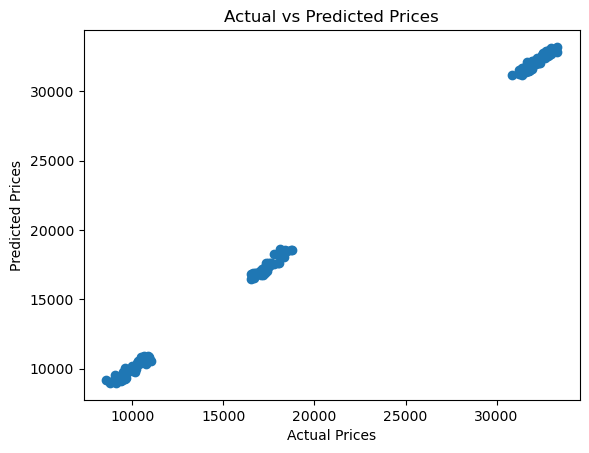

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# Evaluate the Random Forest model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"R2 Score: {r2}")
print(f"Mean Absolute Error: {mae}")

# Plot actual vs predicted prices
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

In [ ]:
import joblib

# Save the trained Random Forest model
joblib.dump(model, 'random_forest_model.pkl')

# Save the fitted scaler
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

testing

In [ ]:
import numpy as np

# Test the model on a few samples from the test set

# Select a few sample indices from the test set
sample_indices = [0, 10, 20, 30, 40]  # You can change these indices

for i in sample_indices:
	# Reshape the sample to match the input shape
	sample = X_test[i].reshape(1, -1)
	# Make prediction
	pred = model.predict(sample)
	# Get actual value
	actual = y_test.iloc[i]
	# Print comparison
	print(f"Sample {i}: Actual Price: ${actual:.2f}, Predicted Price: ${pred[0]:.2f}")

Sample 0: Actual Price: $10900.50, Predicted Price: $10674.70
Sample 10: Actual Price: $10194.66, Predicted Price: $9950.79
Sample 20: Actual Price: $10359.76, Predicted Price: $10520.27
Sample 30: Actual Price: $17045.60, Predicted Price: $16782.18
Sample 40: Actual Price: $32396.81, Predicted Price: $32043.71


In [ ]:
# Train the Random Forest model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
